In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

# Colours
COL_PD      = '#ca3335'
COL_HEALTHY = '#467ba7'
COL_SIG     = "#519BD4"   # significant bar
COL_NONSIG  = "#E9F0B3"   # non-significant bar

In [17]:
df = pd.read_csv('data/2025_parkinsons.csv')

# Extract subject ID from the name column (e.g. 'phon_R01_S01_1' -> 'phon_R01_S01')
df['subject'] = df['name'].str.rsplit('_', n=1).str[0]

# Split into healthy/non healty
pd_group = df[df['status'] == 1]
healthy_group = df[df['status'] == 0]

# All 22 vocal features (exclude name, subject, status)
features = [c for c in df.columns if c not in ['name', 'subject', 'status']]

print(f'Total recordings: {len(df)}')
print(f'PD recordings: {len(pd_group)} ({len(pd_group.subject.unique())} subjects)')
print(f'Healthy recordings: {len(healthy_group)} ({len(healthy_group.subject.unique())} subjects)')
print(f'Number of features: {len(features)}')
print(f'Class balance (PD %): {len(pd_group)/len(df)*100:.1f}%')

Total recordings: 195
PD recordings: 146 (24 subjects)
Healthy recordings: 47 (8 subjects)
Number of features: 22
Class balance (PD %): 74.9%


In [18]:
# Mann-Whitney U for all features
results = []

for feat in features:
    a = pd_group[feat].dropna().values
    b = healthy_group[feat].dropna().values

    # Mann-Whitney U test (two-sided)
    U, p_raw = stats.mannwhitneyu(a, b, alternative='two-sided')

    # Rank-biserial correlation as effect size (Kerby 2014)
    # r = (2U / (n_pd * n_healthy)) - 1
    # r > 0 → PD tends to have HIGHER values; r < 0 → PD tends to be LOWER
    n_pd = len(a)
    n_h  = len(b)
    r    = (2 * U) / (n_pd * n_h) - 1

    # Medians per group
    median_pd      = np.median(a)
    median_healthy = np.median(b)

    results.append({
        'feature'        : feat,
        'U'              : U,
        'p_raw'          : p_raw,
        'effect_size_r'  : r,
        'abs_r'          : abs(r),
        'median_PD'      : median_pd,
        'median_healthy' : median_healthy,
        'direction'      : 'PD > healthy' if median_pd > median_healthy else 'PD < healthy'
    })

results_df = pd.DataFrame(results)

# Benjamini-Hochberg FDR correction
reject, p_corrected, _, _ = multipletests(results_df['p_raw'], alpha=0.05, method='fdr_bh')
results_df['p_corrected'] = p_corrected
results_df['significant'] = reject

# Sort by effect size (descending)
results_df = results_df.sort_values('abs_r', ascending=False).reset_index(drop=True)

print(f"Significant features: {results_df['significant'].sum()} out of {len(features)}")

Significant features: 22 out of 22


In [19]:
display_df = results_df[['feature','median_PD','median_healthy','direction','U','p_raw','p_corrected','effect_size_r','significant']].copy()
display_df.columns = ['Feature','Median (PD)','Median (healthy)','Direction','U','p (raw)','p (FDR)','Effect size r','Significant']

# Format floats
for col in ['Median (PD)','Median (healthy)','p (raw)','p (FDR)','Effect size r']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')
display_df['U'] = display_df['U'].apply(lambda x: f'{x:.0f}')

display_df

,Feature,Median (PD),Median (healthy),Direction,U,p (raw),p (FDR),Effect size r,Significant
0,PPE,0.2218,0.1174,PD > healthy,6135,0.0000,0.0000,0.7881,True
1,spread1,-5.4426,-6.8161,PD > healthy,6135,0.0000,0.0000,0.7881,True
2,MDVP:APQ,0.0215,0.0132,PD > healthy,5634,0.0000,0.0000,0.6419,True
3,spread2,0.2403,0.1645,PD > healthy,5571,0.0000,0.0000,0.6237,True
4,MDVP:Jitter(Abs),0.0000,0.0000,PD > healthy,5377,0.0000,0.0000,0.5672,True
5,MDVP:PPQ,0.0031,0.0018,PD > healthy,5324,0.0000,0.0000,0.5626,True
6,MDVP:Shimmer(dB),0.2600,0.1540,PD > healthy,5224,0.0000,0.0000,0.5558,True
7,MDVP:RAP,0.0028,0.0016,PD > healthy,5289,0.0000,0.0000,0.5522,True
8,MDVP:Shimmer,0.0283,0.0170,PD > healthy,5192,0.0000,0.0000,0.5462,True
9,Jitter:DDP,0.0085,0.0050,PD > healthy,5266,0.0000,0.0000,0.5453,True


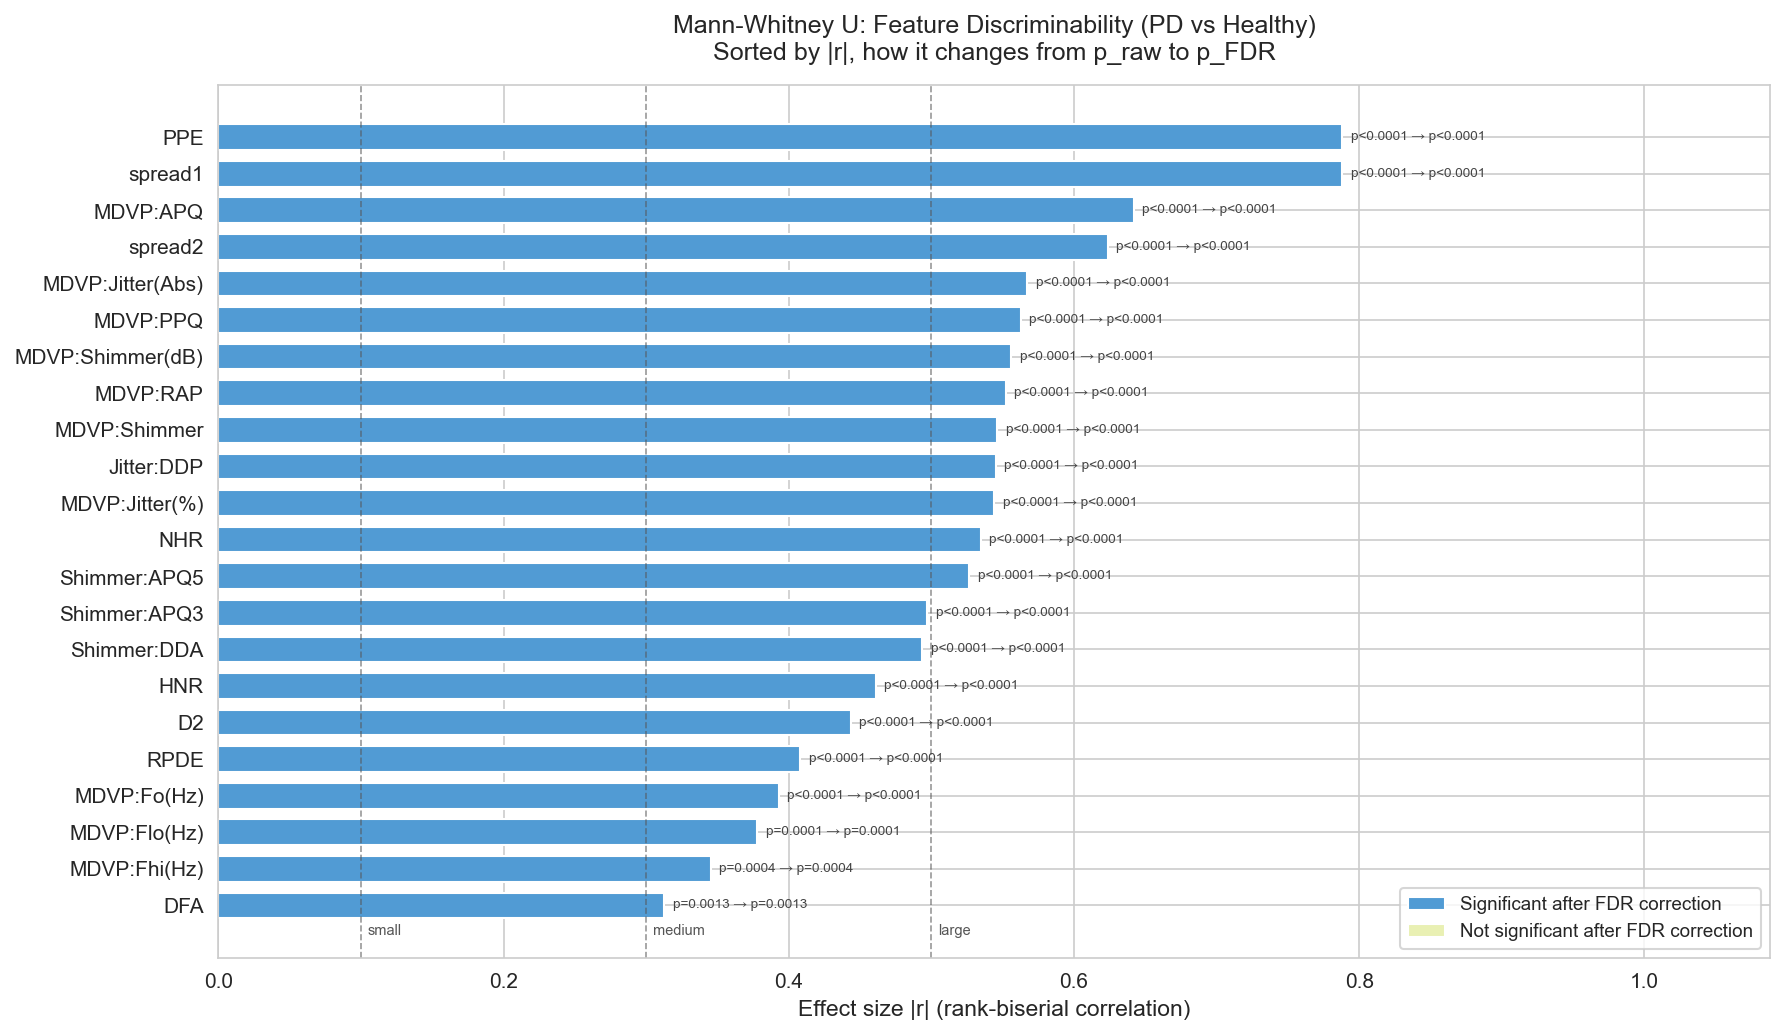

Features significant before FDR correction: 22 out of 22
Features significant after  FDR correction: 22 out of 22
Features that lost significance after correction: 0


In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

colours = [COL_SIG if s else COL_NONSIG for s in results_df['significant']]
ax.barh(
    results_df['feature'],
    results_df['abs_r'],
    color=colours,
    edgecolor='white',
    height=0.7
)

# Reference lines for effect size benchmarks
for x, label in [(0.1, 'small'), (0.3, 'medium'), (0.5, 'large')]:
    ax.axvline(x, color='#555555', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(x + 0.005, len(features) - 0.5, label, fontsize=7, color='#555555', va='top')

def fmt_p(p):
    if p < 0.0001:
        return 'p<0.0001'
    return f'p={p:.4f}'

for i, (_, row) in enumerate(results_df.iterrows()):
    sig_before = row['p_raw'] < 0.05
    sig_after  = row['significant']
    lost_sig   = sig_before and not sig_after

    annotation = f"{fmt_p(row['p_raw'])} → {fmt_p(row['p_corrected'])}"
    txt_color  = '#cc0000' if lost_sig else '#444444'
    ax.text(
        row['abs_r'] + 0.006, i,
        annotation,
        va='center', ha='left', fontsize=6.5, color=txt_color
    )
    if lost_sig:
        ax.text(row['abs_r'] + 0.002, i, ' ✗ lost sig', va='center',
                ha='left', fontsize=7, color='#cc0000', fontweight='bold')

ax.set_xlabel('Effect size |r| (rank-biserial correlation)', fontsize=11)
ax.set_title(
    'Mann-Whitney U: Feature Discriminability (PD vs Healthy)\n'
    'Sorted by |r|, how it changes from p_raw to p_FDR',

    fontsize=12, pad=12
)
ax.invert_yaxis()
ax.set_xlim(0, min(results_df['abs_r'].max() + 0.30, 1.25))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COL_SIG,    label='Significant after FDR correction'),
    Patch(facecolor=COL_NONSIG, label='Not significant after FDR correction'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('plots/mann_whitney_effect_sizes.png', dpi=200, bbox_inches='tight')
plt.show()

n_lost = ((results_df['p_raw'] < 0.05) & ~results_df['significant']).sum()
print(f"Features significant before FDR correction: {(results_df['p_raw'] < 0.05).sum()} out of {len(features)}")
print(f"Features significant after  FDR correction: {results_df['significant'].sum()} out of {len(features)}")
print(f"Features that lost significance after correction: {n_lost}")

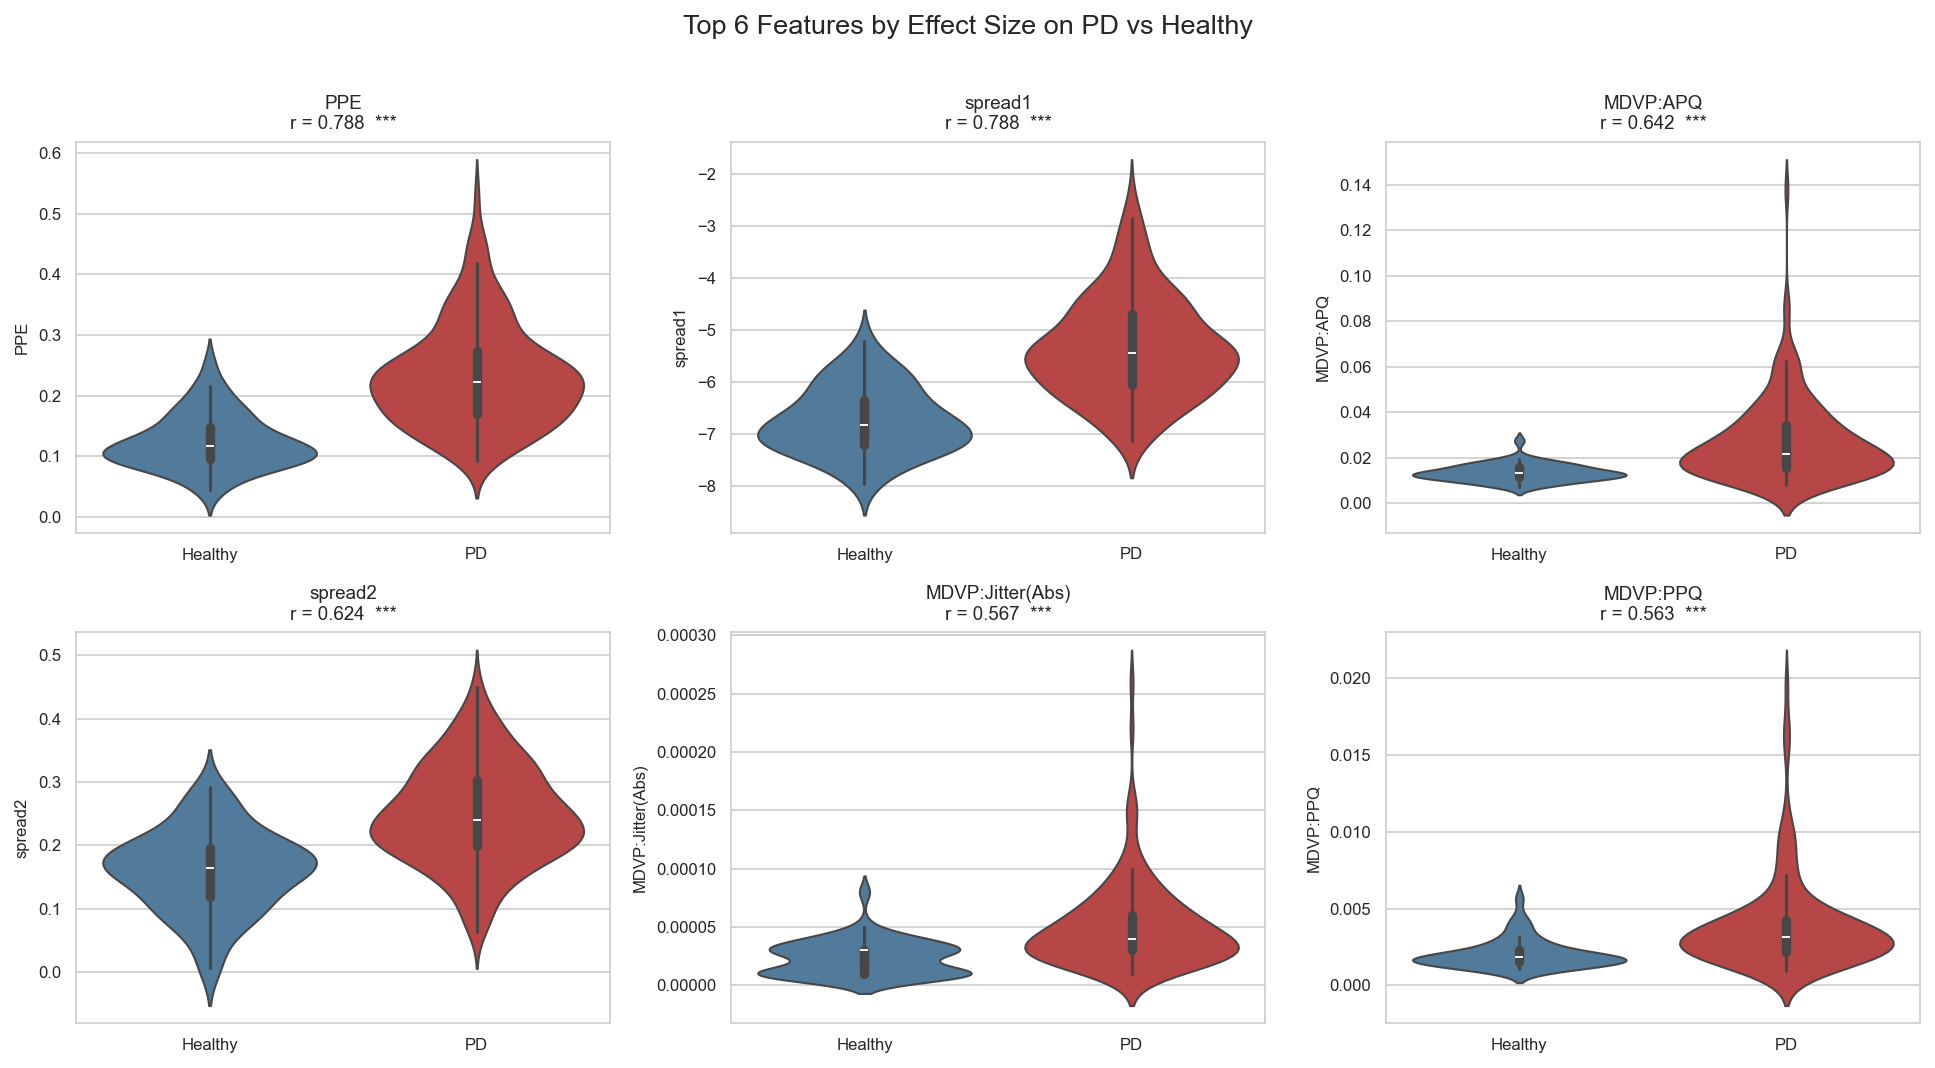

In [21]:
top_features = results_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    plot_df = df[['status', feat]].copy()
    plot_df['Diagnosis'] = plot_df['status'].map({1: 'PD', 0: 'Healthy'})

    sns.violinplot(
        data=plot_df, x='Diagnosis', y=feat,
        hue='Diagnosis',
        palette={'PD': COL_PD, 'Healthy': COL_HEALTHY},
        order=['Healthy', 'PD'],
        inner='box', ax=ax, linewidth=1, legend=False
    )

    row = results_df[results_df['feature'] == feat].iloc[0]
    sig_marker = '***' if row['p_corrected'] < 0.001 else ('**' if row['p_corrected'] < 0.01 else ('*' if row['p_corrected'] < 0.05 else 'ns'))
    ax.set_title(f"{feat}\nr = {row['effect_size_r']:.3f}  {sig_marker}", fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel(feat, fontsize=8)
    ax.tick_params(labelsize=8)

fig.suptitle('Top 6 Features by Effect Size on PD vs Healthy', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/mann_whitney_top_features.png', dpi=200, bbox_inches='tight')
plt.show()

In [22]:
sig = results_df[results_df['significant']]
nonsig = results_df[~results_df['significant']]

print('Mann-Whitney U results summary')
print(f'Total features tested: {len(features)}')
print(f'Significant after FDR (0.05): {len(sig)}')
print(f'Not significant: {len(nonsig)}')
print()
print('Top 5 features by effect size:')
for _, row in results_df.head(5).iterrows():
    print(f"{row['feature']}  r = {row['effect_size_r']:+.3f}  p_FDR = {row['p_corrected']:.4f}  [{row['direction']}]")
print()
if len(nonsig) > 0:
    print('Non-significant features (after FDR correction):')
    for _, row in nonsig.iterrows():
        print(f"  {row['feature']}  r = {row['effect_size_r']:+.3f}  p_FDR = {row['p_corrected']:.4f}")
print()
print('Interpretation:')
print('r > 0 -> PD tends to have HIGHER values (e.g. more jitter/shimmer = more vocal instability)')
print('r < 0 -> PD tends to have LOWER values (e.g. lower HNR, lower fundamental frequency)')
print('|r| > 0.5 -> large effect, strong discriminator between groups')

Mann-Whitney U results summary
Total features tested: 22
Significant after FDR (0.05): 22
Not significant: 0

Top 5 features by effect size:
PPE  r = +0.788  p_FDR = 0.0000  [PD > healthy]
spread1  r = +0.788  p_FDR = 0.0000  [PD > healthy]
MDVP:APQ  r = +0.642  p_FDR = 0.0000  [PD > healthy]
spread2  r = +0.624  p_FDR = 0.0000  [PD > healthy]
MDVP:Jitter(Abs)  r = +0.567  p_FDR = 0.0000  [PD > healthy]


Interpretation:
r > 0 -> PD tends to have HIGHER values (e.g. more jitter/shimmer = more vocal instability)
r < 0 -> PD tends to have LOWER values (e.g. lower HNR, lower fundamental frequency)
|r| > 0.5 -> large effect, strong discriminator between groups
